In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_ipl = pd.read_csv("../data/processed/ipl_deliveries.csv")
print(f"Loaded: {df_ipl.shape}")

Loaded: (278034, 25)


In [4]:
# Calculate average powerplay score per team per season (2021-2025)
# Powerplay = first 6 overs (over index 0-5)
# Uses runs_total to capture all runs including extras — reflects actual scoreboard pressure

# Step 1: Filter to powerplay deliveries for 2021 onwards
powerplay = df_ipl[
    (df_ipl['over'] <= 5) &        # first 6 overs only
    (df_ipl['season'] >= 2021)     # 2021-2025 seasons only
]

# Step 2: Sum runs per innings (per match per team) to get powerplay score for each game
pp_per_match = (powerplay
                .groupby(['season', 'batting_team', 'match_id'])['runs_total']
                .sum()
                .reset_index())    # one row per team per match

# Step 3: Average those innings totals across the season to get avg powerplay score
pp_runs = (pp_per_match
           .groupby(['season', 'batting_team'])['runs_total']
           .mean()
           .reset_index()
           .rename(columns={'runs_total': 'avg_pp_runs'}))  # rename for clarity

# Display sorted by season and avg powerplay runs descending
print(pp_runs
      .sort_values(['season', 'avg_pp_runs'], ascending=[True, False])
      .to_string(index=False))

 season                batting_team  avg_pp_runs
   2021              Delhi Capitals    48.812500
   2021              Mumbai Indians    48.285714
   2021 Royal Challengers Bengaluru    47.066667
   2021         Sunrisers Hyderabad    46.785714
   2021       Kolkata Knight Riders    46.705882
   2021         Chennai Super Kings    45.500000
   2021            Rajasthan Royals    44.500000
   2021                Punjab Kings    42.500000
   2022                Punjab Kings    55.214286
   2022              Delhi Capitals    54.142857
   2022            Rajasthan Royals    50.235294
   2022              Gujarat Titans    46.250000
   2022         Chennai Super Kings    45.000000
   2022              Mumbai Indians    44.714286
   2022        Lucknow Super Giants    44.666667
   2022       Kolkata Knight Riders    43.571429
   2022 Royal Challengers Bengaluru    43.500000
   2022         Sunrisers Hyderabad    42.142857
   2023            Rajasthan Royals    56.428571
   2023         Chen

In [5]:
# Calculate season rankings based on wins per team per season
# We derive rankings from match results since we don't have an external standings table

# Step 1: Get one row per match per team (avoid counting both innings)
match_results = (df_ipl[df_ipl['innings'] == 1]  # one row per match is enough
                 .groupby(['season', 'match_id', 'batting_team', 'winner'])
                 .size()
                 .reset_index()
                 .drop(columns=0))

# Step 2: Flag whether the batting team won that match
match_results['win'] = (match_results['batting_team'] == match_results['winner']).astype(int)

# Step 3: Count total wins and matches per team per season
standings = (match_results
             .groupby(['season', 'batting_team'])
             .agg(
                 wins=('win', 'sum'),           # total wins
                 matches=('match_id', 'count')  # total matches played
             )
             .reset_index())

# Step 4: Rank teams within each season by wins (1 = most wins)
standings['rank'] = (standings
                     .groupby('season')['wins']
                     .rank(ascending=False, method='min')
                     .astype(int))

# Step 5: Merge powerplay runs with standings
pp_vs_rank = pp_runs.merge(
    standings[['season', 'batting_team', 'wins', 'rank']],
    on=['season', 'batting_team'],
    how='inner'
)

print(pp_vs_rank.sort_values(['season', 'rank']).to_string(index=False))

 season                batting_team  avg_pp_runs  wins  rank
   2021         Chennai Super Kings    45.500000     5     1
   2021              Mumbai Indians    48.285714     3     2
   2021                Punjab Kings    42.500000     3     2
   2021       Kolkata Knight Riders    46.705882     2     4
   2021            Rajasthan Royals    44.500000     2     4
   2021              Delhi Capitals    48.812500     1     6
   2021         Sunrisers Hyderabad    46.785714     1     6
   2021 Royal Challengers Bengaluru    47.066667     0     8
   2022        Lucknow Super Giants    44.666667     7     1
   2022            Rajasthan Royals    50.235294     7     1
   2022              Gujarat Titans    46.250000     4     3
   2022                Punjab Kings    55.214286     4     3
   2022         Chennai Super Kings    45.000000     3     5
   2022              Delhi Capitals    54.142857     3     5
   2022       Kolkata Knight Riders    43.571429     2     7
   2022              Mum

Correlation between avg powerplay runs and season rank: -0.241

Correlation by season:
  2021: 0.435
  2022: -0.498
  2023: -0.114
  2024: -0.716
  2025: -0.296


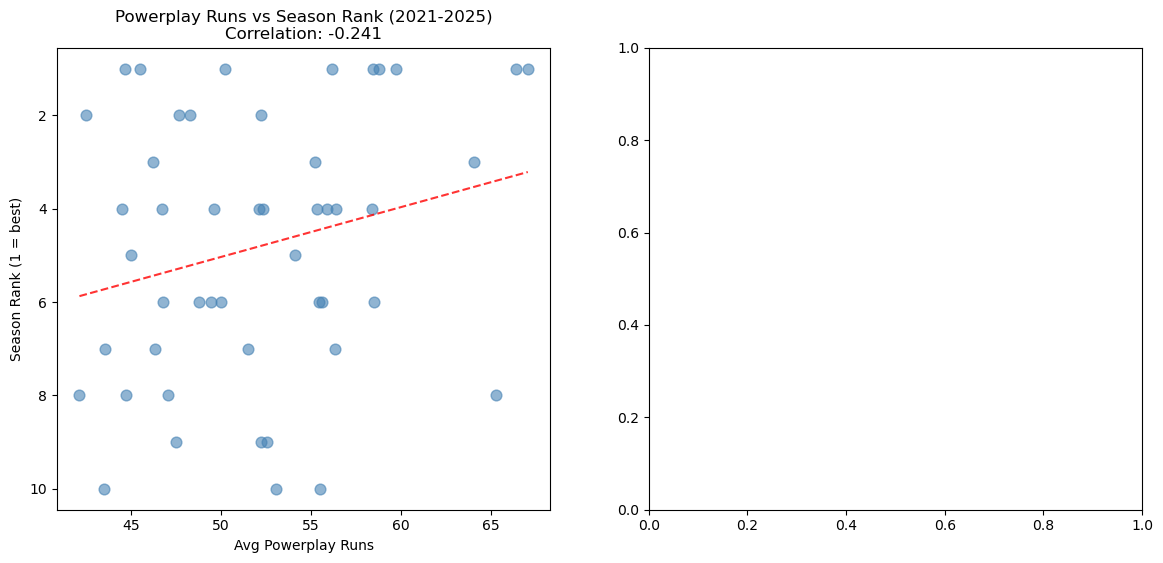

In [6]:
# Calculate correlation between avg powerplay runs and season rank
# Note: rank 1 = best, so we expect negative correlation (higher pp runs = lower rank number)

# Step 1: Calculate Pearson correlation coefficient
correlation = pp_vs_rank['avg_pp_runs'].corr(pp_vs_rank['rank'])
print(f"Correlation between avg powerplay runs and season rank: {correlation:.3f}")

# Step 2: Also calculate per season to see if correlation has changed over time
print("\nCorrelation by season:")
for season in sorted(pp_vs_rank['season'].unique()):
    season_data = pp_vs_rank[pp_vs_rank['season'] == season]
    corr = season_data['avg_pp_runs'].corr(season_data['rank'])
    print(f"  {season}: {corr:.3f}")

# Step 3: Scatter plot — avg powerplay runs vs season rank
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: all seasons combined
axes[0].scatter(pp_vs_rank['avg_pp_runs'], pp_vs_rank['rank'],
                alpha=0.6, color='steelblue', s=60)
# Add trend line
z = np.polyfit(pp_vs_rank['avg_pp_runs'], pp_vs_rank['rank'], 1)
p = np.poly1d(z)
x_line = np.linspace(pp_vs_rank['avg_pp_runs'].min(),
                     pp_vs_rank['avg_pp_runs'].max(), 100)
axes[0].plot(x_line, p(x_line), color='red', linestyle='--', alpha=0.8)
axes[0].set_xlabel('Avg Powerplay Runs')
axes[0].set_ylabel('Season Rank (1 = best)')
axes[0].set_title(f'Powerplay Runs vs Season Rank (2021-2025)\nCorrelation: {correlation:.3f}')
axes[0].invert_yaxis()  # rank 1 at top

# Right plot: correlation by season as bar chart
seasons = sorted(pp_vs_rank['season'].unique())
corrs = [pp_vs_rank[pp_vs_rank['season'] == s]['avg_pp_runs']
         .corr(pp_vs_rank[pp_vs_rank['season'] == s]['rank']) for s in seasons]
colors = ['green' if c < 0 else 'red' for c in corrs]  #

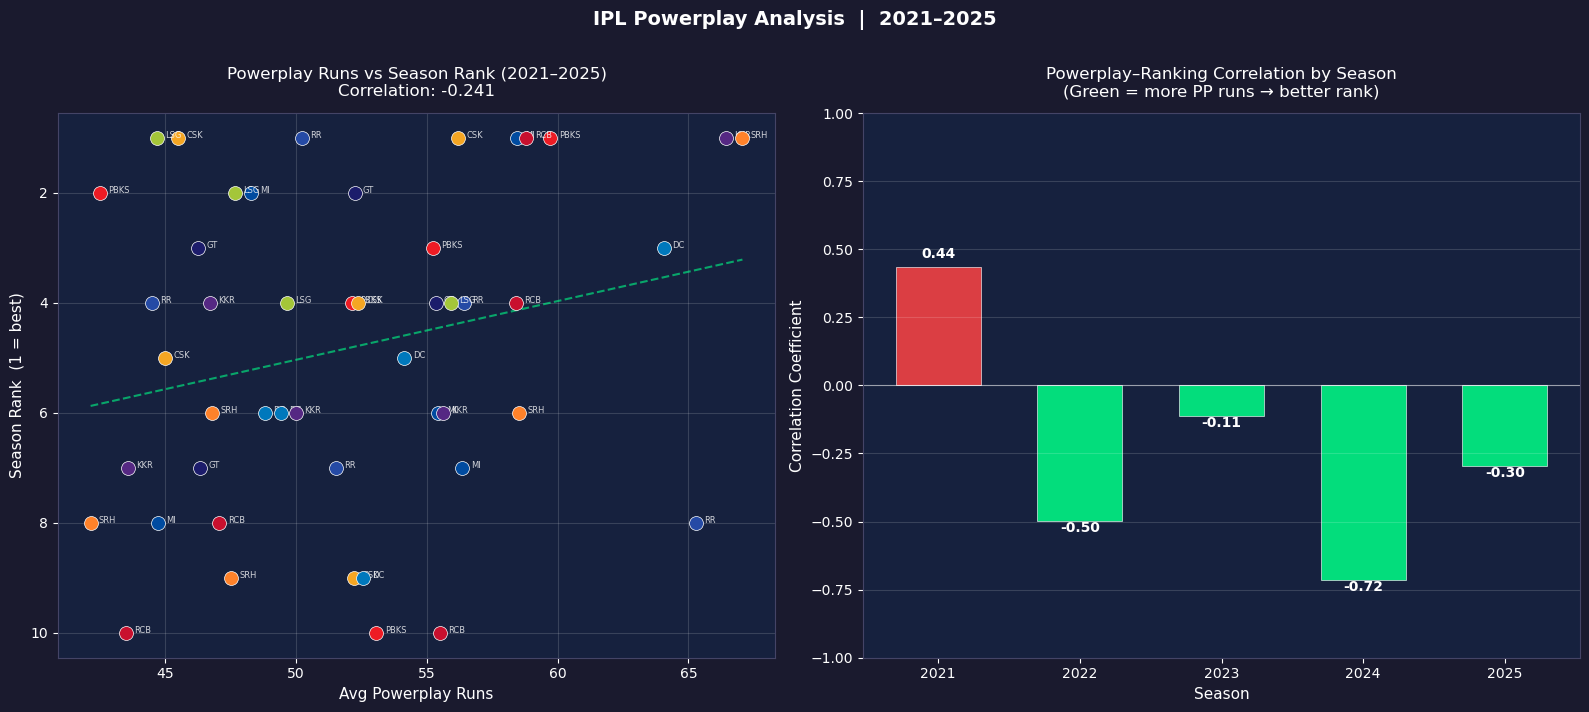

Plot saved


In [8]:
# Cricket-themed scatter plot — powerplay runs vs season rank
# Uses official IPL team colours instead of logos (cleaner and copyright-safe)

# Team colour mapping — official IPL brand colours
TEAM_COLOURS = {
    'Chennai Super Kings':          '#F5A623',   # CSK yellow
    'Mumbai Indians':               '#004BA0',   # MI blue
    'Royal Challengers Bengaluru':  '#C8102E',   # RCB red
    'Kolkata Knight Riders':        '#552883',   # KKR purple
    'Delhi Capitals':               '#0078BC',   # DC blue
    'Sunrisers Hyderabad':          '#FF822A',   # SRH orange
    'Rajasthan Royals':             '#254AA5',   # RR blue/pink
    'Punjab Kings':                 '#ED1B24',   # PBKS red
    'Gujarat Titans':               '#1C1C6B',   # GT navy
    'Lucknow Super Giants':         '#A4C639',   # LSG green
}

# Team abbreviations for annotations
TEAM_ABBR = {
    'Chennai Super Kings':          'CSK',
    'Mumbai Indians':               'MI',
    'Royal Challengers Bengaluru':  'RCB',
    'Kolkata Knight Riders':        'KKR',
    'Delhi Capitals':               'DC',
    'Sunrisers Hyderabad':          'SRH',
    'Rajasthan Royals':             'RR',
    'Punjab Kings':                 'PBKS',
    'Gujarat Titans':               'GT',
    'Lucknow Super Giants':         'LSG',
}

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1a1a2e')  # dark background

for ax in axes:
    ax.set_facecolor('#16213e')      # dark panel background
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

# ── Left plot: scatter all seasons ───────────────────────────────────────────
for _, row in pp_vs_rank.iterrows():
    colour = TEAM_COLOURS.get(row['batting_team'], 'grey')
    abbr   = TEAM_ABBR.get(row['batting_team'], row['batting_team'][:3])
    axes[0].scatter(row['avg_pp_runs'], row['rank'],
                    color=colour, s=100, zorder=3, edgecolors='white', linewidth=0.5)
    axes[0].annotate(abbr,
                     (row['avg_pp_runs'], row['rank']),
                     textcoords='offset points', xytext=(6, 0),
                     fontsize=6, color='white', alpha=0.8)

# Trend line
z = np.polyfit(pp_vs_rank['avg_pp_runs'], pp_vs_rank['rank'], 1)
p = np.poly1d(z)
x_line = np.linspace(pp_vs_rank['avg_pp_runs'].min(),
                     pp_vs_rank['avg_pp_runs'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#00ff88',
             linestyle='--', alpha=0.6, linewidth=1.5, label='Trend')

axes[0].invert_yaxis()  # rank 1 at top
axes[0].set_xlabel('Avg Powerplay Runs', fontsize=11)
axes[0].set_ylabel('Season Rank  (1 = best)', fontsize=11)
axes[0].set_title(f'Powerplay Runs vs Season Rank (2021–2025)\nCorrelation: {correlation:.3f}',
                  fontsize=12, pad=12)
axes[0].grid(alpha=0.15, color='white')

# ── Right plot: correlation by season bar chart ───────────────────────────────
seasons      = sorted(pp_vs_rank['season'].unique())
season_corrs = [
    pp_vs_rank[pp_vs_rank['season'] == s]['avg_pp_runs']
    .corr(pp_vs_rank[pp_vs_rank['season'] == s]['rank'])
    for s in seasons
]

bar_colours = ['#00ff88' if c < 0 else '#ff4444' for c in season_corrs]
bars = axes[1].bar([str(s) for s in seasons], season_corrs,
                   color=bar_colours, alpha=0.85, width=0.6, edgecolor='white', linewidth=0.5)

# Annotate each bar with its value
for bar, val in zip(bars, season_corrs):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + (0.02 if val >= 0 else -0.05),
                 f'{val:.2f}', ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')

axes[1].axhline(y=0, color='white', linestyle='-', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel('Season', fontsize=11)
axes[1].set_ylabel('Correlation Coefficient', fontsize=11)
axes[1].set_title('Powerplay–Ranking Correlation by Season\n(Green = more PP runs → better rank)',
                  fontsize=12, pad=12)
axes[1].grid(alpha=0.15, color='white', axis='y')
axes[1].set_ylim(-1, 1)  # fix axis to full correlation range

# ── Save ──────────────────────────────────────────────────────────────────────
plt.suptitle('IPL Powerplay Analysis  |  2021–2025',
             fontsize=14, color='white', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/pp_vs_rank.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Plot saved")

In [9]:
# Invert rank so higher number = better performance
# This makes positive correlation = more PP runs → better rank (more intuitive)
pp_vs_rank['rank_inverted'] = pp_vs_rank.groupby('season')['wins'].rank(
    ascending=True, method='min').astype(int)

# Recalculate correlation using inverted rank
correlation = pp_vs_rank['avg_pp_runs'].corr(pp_vs_rank['rank_inverted'])
print(f"Correlation (inverted): {correlation:.3f}")

print("\nCorrelation by season:")
for season in sorted(pp_vs_rank['season'].unique()):
    s = pp_vs_rank[pp_vs_rank['season'] == season]
    corr = s['avg_pp_runs'].corr(s['rank_inverted'])
    print(f"  {season}: {corr:.3f}")

Correlation (inverted): 0.337

Correlation by season:
  2021: -0.434
  2022: 0.479
  2023: 0.158
  2024: 0.824
  2025: 0.379


In [10]:
bar_colours = ['#00ff88' if c > 0 else '#ff4444' for c in season_corrs]

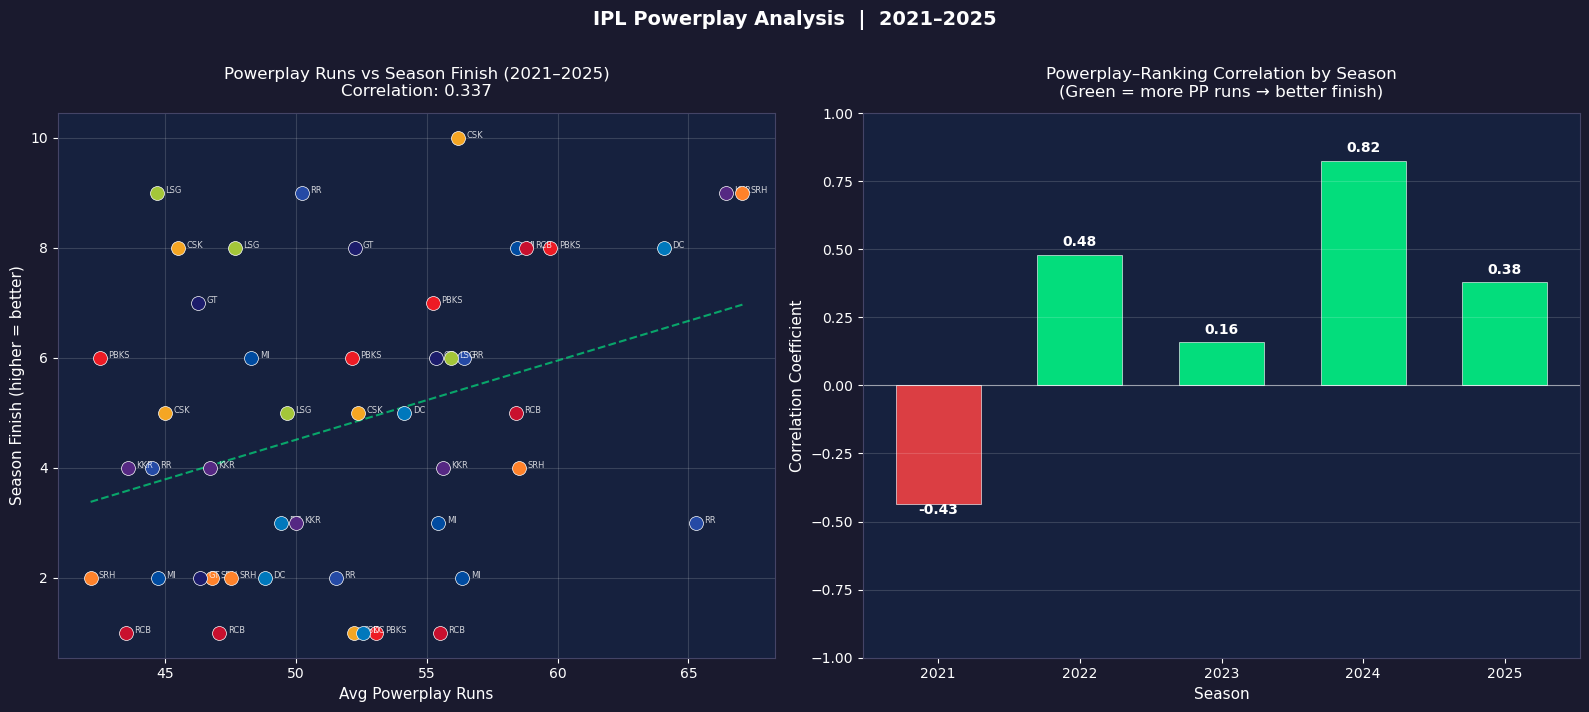

Plot saved


In [11]:
# Cricket-themed scatter plot with inverted rank (higher = better finish)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

# ── Left plot: scatter all seasons ───────────────────────────────────────────
for _, row in pp_vs_rank.iterrows():
    colour = TEAM_COLOURS.get(row['batting_team'], 'grey')
    abbr   = TEAM_ABBR.get(row['batting_team'], row['batting_team'][:3])
    axes[0].scatter(row['avg_pp_runs'], row['rank_inverted'],
                    color=colour, s=100, zorder=3, edgecolors='white', linewidth=0.5)
    axes[0].annotate(abbr,
                     (row['avg_pp_runs'], row['rank_inverted']),
                     textcoords='offset points', xytext=(6, 0),
                     fontsize=6, color='white', alpha=0.8)

# Trend line
z = np.polyfit(pp_vs_rank['avg_pp_runs'], pp_vs_rank['rank_inverted'], 1)
p = np.poly1d(z)
x_line = np.linspace(pp_vs_rank['avg_pp_runs'].min(),
                     pp_vs_rank['avg_pp_runs'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#00ff88',
             linestyle='--', alpha=0.6, linewidth=1.5)

axes[0].set_xlabel('Avg Powerplay Runs', fontsize=11)
axes[0].set_ylabel('Season Finish (higher = better)', fontsize=11)
axes[0].set_title(f'Powerplay Runs vs Season Finish (2021–2025)\nCorrelation: {correlation:.3f}',
                  fontsize=12, pad=12)
axes[0].grid(alpha=0.15, color='white')

# ── Right plot: correlation by season ────────────────────────────────────────
seasons      = sorted(pp_vs_rank['season'].unique())
season_corrs = [
    pp_vs_rank[pp_vs_rank['season'] == s]['avg_pp_runs']
    .corr(pp_vs_rank[pp_vs_rank['season'] == s]['rank_inverted'])
    for s in seasons
]

bar_colours = ['#00ff88' if c > 0 else '#ff4444' for c in season_corrs]
bars = axes[1].bar([str(s) for s in seasons], season_corrs,
                   color=bar_colours, alpha=0.85, width=0.6,
                   edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, season_corrs):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + (0.02 if val >= 0 else -0.05),
                 f'{val:.2f}', ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')

axes[1].axhline(y=0, color='white', linestyle='-', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel('Season', fontsize=11)
axes[1].set_ylabel('Correlation Coefficient', fontsize=11)
axes[1].set_title('Powerplay–Ranking Correlation by Season\n(Green = more PP runs → better finish)',
                  fontsize=12, pad=12)
axes[1].grid(alpha=0.15, color='white', axis='y')
axes[1].set_ylim(-1, 1)

plt.suptitle('IPL Powerplay Analysis  |  2021–2025',
             fontsize=14, color='white', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/pp_vs_rank.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Plot saved")